# Incorporating Fluence Uncertainties in Single Event Effect Measurements — Python / SciPy notebook

This notebook translates the paper's ROOT/C++ probability snippets many additional equations into Python mainly using SciPy. The goal is to make the paper's equations executable and easy to change as desired.

Core notation used here:

$$\begin{array}{ll}
m & \text{: observed number of upsets} \\
c & \text{: one-sided confidence level, e.g. } 0.95 \\
\Phi_0 & \text{: nominal fluence} \\
\delta_0 & \text{: absolute fluence standard deviation} \\
f = \delta_0 / \Phi_0 & \text{: fractional fluence uncertainty (normalized standard deviation)} \\
u = \Phi / \Phi_0 & \text{: normalized (sample/predicted) ratio of fluence, modeled as } \mathcal{N}(1, f^2) \text{ but truncated at } u > 0 \\
\Sigma = \sigma \cdot \Phi_0 & \text{: trial Poisson mean at nominal fluence}
\end{array}$$


A key idea is that for known fluence:
$$m\sim \mathrm{Poisson}(\Sigma)$$

But when there's uncertainty in fluence measurement, the poisson mean ($\Sigma * u$) has an element of uncertainty captured by the u term:
$$m|u\sim \mathrm{Poisson}(\Sigma * u),\qquad u\sim \mathcal{N}(1,f^2).$$

In [28]:

import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import poisson, norm #i think redundant
from scipy.integrate import quad
from scipy.special import erf
from scipy.optimize import root_scalar

# Default test case used in several parts of the paper
m = 5
c = 0.90
f = 0.1



## 1. Cumulative Probability Sums Using SciPy

The paper's ROOT snippets:

```cpp
ROOT::Math::poisson_cdf_c(m, x)      // upper one-sided probability
ROOT::Math::poisson_cdf(m-1, x)      // lower one-sided probability
```

translate to SciPy as:

```python
poisson.sf(m, x)       # P(N > m), same as sum from i=m+1 to infinity
poisson.cdf(m-1, x)   # P(N <= m-1), same as sum from i=0 to m-1
```

where `x` is the Poisson mean.

If m and mu0 are inputted, the result would be the probability of a result higher than or lower than m

In [29]:

x = m #just as an example

def poisson_upper_prob(m, x):
    """Equivalent to ROOT::Math::poisson_cdf_c(m, x).
    Returns P(N > m) for N ~ Poisson(x).
    """
    return poisson.sf(m, x) #sf stands for 'survival function'


def poisson_lower_prob(m, x):
    """Equivalent to ROOT::Math::poisson_cdf(m-1, x).
    Returns P(N <= m-1) for N ~ Poisson(x).
    """
    if m < 1:
        return np.nan
    return poisson.cdf(m - 1, x)


print(f'For m = {m}, x = m:')
print('Upper probability P(N > m):', poisson_upper_prob(m, x))
print('Lower probability P(N <= m-1):', poisson_lower_prob(m, x))


For m = 5, x = m:
Upper probability P(N > m): 0.384039345166937
Lower probability P(N <= m-1): 0.44049328506521257



## 2. Solving for Unsmeared Confidence Limits

For no fluence uncertainty, the confidence limits are found by setting the sum from part 1 to the specific confidence we're looking for and solving for $\mu_0$.

$$ \frac{\chi^{2}_{\alpha/2, 2x}}{2} \le \lambda \le \frac{\chi^{2}_{1-\alpha/2, 2(x+1)}}{2} $$

In [30]:
# Property: The Poisson curve and the Chi Squared curve are mathematical inverses
# Poisson area is the probability of a certain number of events in a given time frame
# Chi Squared area is the probability of a time frame given a certain number of events


def solve_unsmeared_limit(m, c=0.95, side='upper'):
    """Solve for the Poisson mean giving the desired one-sided confidence level."""
    if side == 'upper':
        # Direct algebraic reversal for the upper Poisson limit
        return 0.5 * stats.chi2.ppf(c, 2 * (m + 1))
        
    if side == 'lower':
        if m < 1:
            return np.nan # edge case for the Chi Squared -> confidence interval formula
        # Direct algebraic reversal for the lower Poisson limit
        return 0.5 * stats.chi2.ppf(1 - c, 2 * m)
        
    raise ValueError("side must be 'upper' or 'lower'")

# Keep the execution and print statements exactly the same
lower_mu = solve_unsmeared_limit(m, c, side='lower')
upper_mu = solve_unsmeared_limit(m, c, side='upper')

print(f'm = {m}, one-sided c = {c}')
print(f'Unsmeared lower mean limit: {lower_mu:.6g}')
print(f'Unsmeared upper mean limit: {upper_mu:.6g}')


m = 5, one-sided c = 0.9
Unsmeared lower mean limit: 2.43259
Unsmeared upper mean limit: 9.27467


## 3. Gaussian Fluence Smearing and the Normalizing Factor

The paper defines f, (fractional) fluence uncertainty:

$$f=\frac{\delta_0}{\Phi_0}$$

and u, ratio of (sample) / (predicted) fluences:

$$u=\frac{\Phi}{\Phi_0}.$$

So if fluence uncertainty can be modeled by a Gaussian, then approximately:

$$u\sim \mathcal{N}(1,f^2).$$

A Gaussian technically allows `u < 0`, which would mean negative fluence. To avoid that, we also show Gaussian truncated to `u > 0` (normalization factor), which is implemented below (although it's essentially negligible and will be ignored in future steps).

This is the Python version of:

```cpp
(1.+ROOT::Math::erf(1./sqrt(2.)/[1]))/2

In [31]:

def gaussian_positive_norm(f):
    """N(f) = probability that Normal(1, f) is positive."""
    if f <= 0:
        return 1.0
    return 0.5 * (1.0 + erf(1.0 / (np.sqrt(2.0) * f))) #loc represents mean, scale the stdev
    # Equivalent: return norm.sf(0, loc=1, scale=f)


def u_pdf(u, f, normalize=True):
    """PDF of u ~ Normal(1, f), optionally renormalized over u > 0."""
    if f <= 0:
        raise ValueError('For f=0, use the unsmeared formulas instead of a PDF.')
    Nf = gaussian_positive_norm(f) if normalize else 1.0
    return norm.pdf(u, loc=1.0, scale=f) / Nf


for f_test in [0.05, 0.10, 0.25]:
    print(f'f={f_test:0.2f}, N(f)={gaussian_positive_norm(f_test):.10f}, probability discarded={1-gaussian_positive_norm(f_test):.3e}')


f=0.05, N(f)=1.0000000000, probability discarded=0.000e+00
f=0.10, N(f)=1.0000000000, probability discarded=0.000e+00
f=0.25, N(f)=0.9999683288, probability discarded=3.167e-05


## 4. Equation (8): Smeared Poisson Probability Integrand Using Scipy

The paper's ROOT-style integrand:

```cpp
ROOT::Math::poisson_cdf_c([0], ([2]*x)) * ROOT::Math::gaussian_pdf(x,[1],1.)
```

maps to:

```python
poisson.sf(m, Sigma*u) * norm.pdf(u, loc=1, scale=f) #loc represents mean, scale the stdev
```
where loc is the horizontal offset

Here:
- `[0]` is `m`
- `[1]` is `f`
- `[2]` is `Sigma`
- `x` is `u`

This integral is the calculation to 

In [32]:
def smeared_probability(Sigma, f_val=f):
    lower = max(0.0, 1.0 - 10.0*f_val)
    upper = 1.0 + 10.0*f_val

    def integrand(u):
        return poisson.sf(m, Sigma * u) * u_pdf(u, f_val, normalize=False)

    value, err = quad(integrand, lower, upper) #quad is scipy's integral function, err is the deviation between approx. and actual integral
    return value

print(f'Smeared Upper Probability P(N>m):', smeared_probability(m))
print(f'Smeared Lower Probability P(N<=m-1):', 1 - smeared_probability(m))



Smeared Upper Probability P(N>m): 0.3841422279289088
Smeared Lower Probability P(N<=m-1): 0.6158577720710912


## 4.5 Exact Numerical Smeared Confidence Limits

To find the true smeared confidence limit, we need to find the exact hypothetical mean $\Sigma$ where our smeared tail probability equals our target confidence `c` (e.g., 0.95). 

Mathematically, because the integral in Section 4 has no clean algebraic inverse, we must use a numerical root-finding algorithm (like Brent's method) to \"guess and check\" $\Sigma$ until the integral equals `c`.

While this is highly accurate, running numerical integration inside a root-finding loop is computationally expensive, which motivates the analytical shortcut developed in the next section.

In [ ]:
def exact_smeared_limit(m, c, f, side='upper'):
    mu0 = solve_unsmeared_limit(m, c, side)
    if (side == 'upper'):
        obj_func = lambda Sigma: smeared_probability(Sigma, f) - c
    else:
        obj_func = lambda Sigma: 1 - smeared_probability(Sigma, f) - c
    return root_scalar(obj_func, bracket=[mu0 * 0.1, mu0 * 3.0]).root

print(f"Exact Lower Limit: {exact_smeared_limit(m, c, f, 'lower'):.4f}")
print(f"Exact Upper Limit: {exact_smeared_limit(m, c, f, 'upper'):.4f}")

''' this is overcomplicated, simplify and replace what's above^^
def exact_smeared_limit(m, c, f, side='upper'):
    mu0 = solve_unsmeared_limit(m, c, side)
    
    if (side == 'upper'):
        # Target: P(N > m) = c
        obj_func = lambda Sigma: smeared_probability(Sigma, f) - c
    else:
        # Target: P(N <= m - 1) = 1 - c
        # You need to calculate the smeared CDF for m-1
        def smeared_cdf_m_minus_1(Sigma, f_val):
            lower = max(0.0, 1.0 - 10.0*f_val)
            upper = 1.0 + 10.0*f_val
            def integrand(u):
                # Use CDF and m-1 here!
                return stats.poisson.cdf(m - 1, Sigma * u) * u_pdf(u, f_val, normalize=False)
            return quad(integrand, lower, upper)[0]

        obj_func = lambda Sigma: smeared_cdf_m_minus_1(Sigma, f) - (1 - c)

    return root_scalar(obj_func, bracket=[mu0 * 0.1, mu0 * 3.0]).root

'''

Exact Lower Limit: 3.1233
Exact Upper Limit: 9.4777


## 5. Taylor correction for the shifted confidence limit

This is the paper's $\alpha$ idea.

Let $\mu_0$ be the old unsmeared confidence limit. The smeared confidence limit is assumed to be close to it:

$$\Sigma = \mu_0 + \alpha.$$

The correction $\alpha$ is found by Taylor expanding the unsmeared probability function and solving approximately. For small `f`, the result is approximately:

$$\alpha\approx -\frac{p''(\mu_0)\mu_0^2}{2p'(\mu_0)}f^2.$$

This cell estimates $p'$ and $p''$ numerically for either the upper or lower probability function. It then updates the confidence interval by calculating alpha


In [34]:
def solve_taylor_limit(m, c, f, side='upper'):
    """Calculates the smeared confidence limit directly via the paper's Taylor shortcut."""
    if side == 'upper':
        # Upper bound uses c directly, and looks at the survival function tail P(N > m)
        mu0 = 0.5 * stats.chi2.ppf(c, 2 * (m + 1))
        p = lambda mu: stats.poisson.sf(m, mu)

    elif side == 'lower':
        # Lower bound uses 1 - c, and looks at the cumulative tail P(N <= m - 1)
        if m < 1: return np.nan, np.nan, np.nan
        mu0 = 0.5 * stats.chi2.ppf(1 - c, 2 * m)
        p = lambda mu: stats.poisson.cdf(m - 1, mu)
    else:
        raise ValueError("side must be 'upper' or 'lower'")

    # 2. Central finite differences (h = 1e-5)
    h = 1e-5 * mu0
    p1 = (p(mu0 + h) - p(mu0 - h)) / (2 * h)
    p2 = (p(mu0 + h) - 2 * p(mu0) + p(mu0 - h)) / (h ** 2)

    # 3. Taylor analytical correction
    alpha = -(p2 * (mu0**2) * (f**2)) / (2 * p1)
    return mu0, alpha, mu0 + alpha

lower_mu0, lower_alpha, lower_smeared = solve_taylor_limit(m, c, f, side='lower')
upper_mu0, upper_alpha, upper_smeared = solve_taylor_limit(m, c, f, side='upper')

print(f"If m = {m}, c = {c}, f = {f}")
print(f"Lower Bound -> mu0: {lower_mu0:.4f} | alpha: {lower_alpha:+.4f} | Limit: {lower_smeared:.4f}")
print(f"Upper Bound -> mu0: {upper_mu0:.4f} | alpha: {upper_alpha:+.4f} | Limit: {upper_smeared:.4f}")

If m = 5, c = 0.9, f = 0.1
Lower Bound -> mu0: 2.4326 | alpha: -0.0191 | Limit: 2.4135
Upper Bound -> mu0: 9.2747 | alpha: +0.1982 | Limit: 9.4729



## 6. Plot smeared confidence curves

This recreates the idea of the paper's confidence-limit plots: increasing `f` changes the curve and therefore moves the crossing with the confidence line (wider confidence interval).


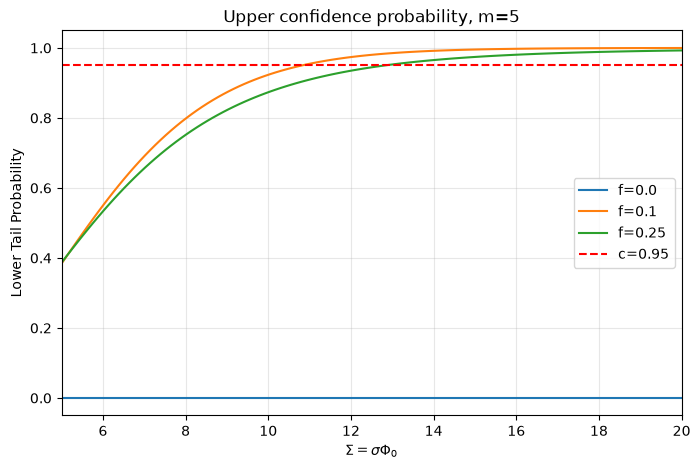

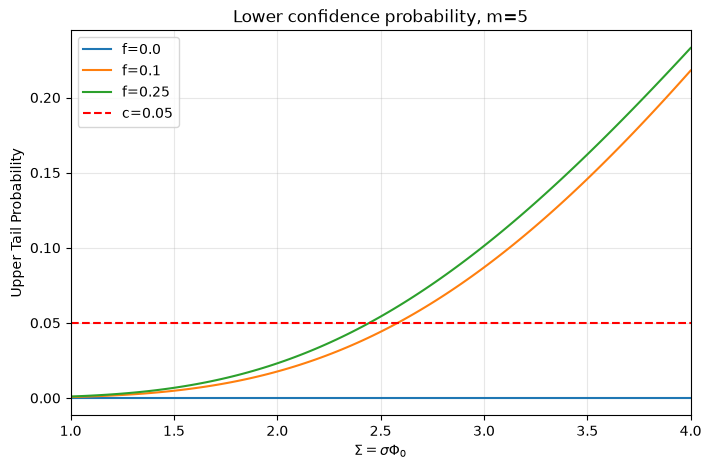

In [35]:
def plot_confidence_curves(m=5, c=0.95, f_values=(0.0, 0.10, 0.25), side='upper', Sigma_max=20, npoints=120, tail_probability='Upper Tail Probability'):
    # Span the grid from the new starting point to Sigma_max
    start_scale = Sigma_max / 4
    Sigmas = np.linspace(start_scale, Sigma_max, npoints)
    
    plt.figure(figsize=(8, 5))
    for f_val in f_values:
        vals = [smeared_probability(S, f_val) for S in Sigmas]
        plt.plot(Sigmas, vals, label=f'f={f_val}')
        
    plt.axhline(c, linestyle='--', color='red', label=f'c={c}')
    
    # Readjust the x-axis scale
    plt.xlim(start_scale, Sigma_max)
    plt.xlabel(r'$\Sigma = \sigma\Phi_0$')
    plt.ylabel(tail_probability)
    plt.title(f'{side.capitalize()} confidence probability, m={m}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Adjusted boundaries to comfortably frame the transitions
plot_confidence_curves(m=5, c=0.95, side='upper', Sigma_max=20, tail_probability='Lower Tail Probability') # Views from Sigma = 5 to 20
plot_confidence_curves(m=5, c=0.05, side='lower', Sigma_max=4, tail_probability='Upper Tail Probability')  # Views from Sigma = 1 to 4

## 7. No-event case and Equation (19)

For `m = 0` (common enough to warrant its own special form), the upper confidence probability is the probability of seeing **any** event:

$$P(N>0)=1-e^{-\mu}$$

Without smearing, solving $1-e^{-\mu_0}=c$ gives:

$$\mu_0=-\ln(1-c)$$

The paper's approximate smeared no-event upper limit is, which is a much simpler form we can use for this specific case:

$$\Sigma \approx \mu_0 + \frac{\mu_0^2}{2(1/f^2-\mu_0)}$$

In [36]:
def no_event_eq19_approx(c, f):
    mu0 = -np.log(1.0 - c)
    approx = mu0 + mu0**2 / (2.0 * (1.0 / f**2 - mu0))
    print(f"c={c}, f={f}: \nΣ = {approx:.6g}")

no_event_eq19_approx(c,f)

c=0.9, f=0.1: 
Σ = 2.32972


## 8. Cross-section bias correction: Equations (21) and (22)

For the estimator

$$\hat\sigma=\frac{m}{\Phi},$$

fluence uncertainty appears in the denominator. With $\Phi=\Phi_0u$, the correction depends on $E[1/u]$.

Using Taylor expansions and simplifying (such as odd terms averaging to 0), we find that the first correction term is $f^2$, and the second correction term is $3f^4$, etc. Every term beyond f^2 has very marginal effects on the prediction (at f=.25, the 4th order term only has ~1% contribution).

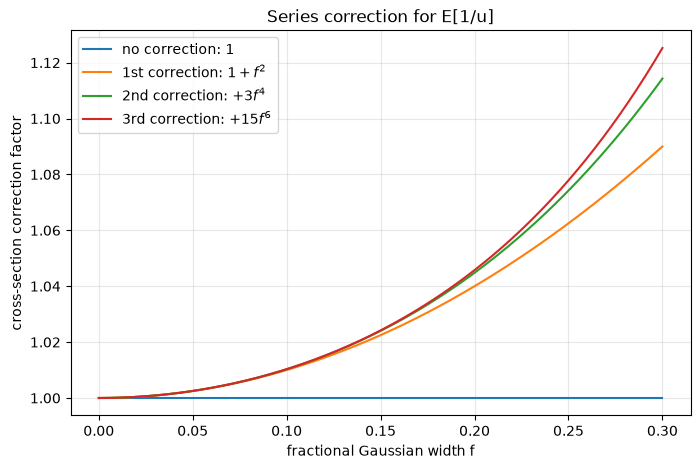

In [37]:
# The graph created isn't the exact same as figure 5, but shows the same general idea

def inv_u_series_correction(f, order=1):
    """Approximate E[1/u] using even Gaussian moments.

    order=0: 1
    order=1: 1 + f^2
    order=2: 1 + f^2 + 3 f^4
    order=3: 1 + f^2 + 3 f^4 + 15 f^6
    """
    coeffs = [1, 1, 3, 15, 105, 945]  # (2k-1)!! for k=0,1,...
    if order >= len(coeffs):
        raise ValueError(f'order must be less than {len(coeffs)}')
    return sum(coeffs[k] * f**(2*k) for k in range(order + 1))


f_grid = np.linspace(0, 0.3, 200)
plt.figure(figsize=(8, 5))
plt.plot(f_grid, [inv_u_series_correction(ff, order=0) for ff in f_grid], label='no correction: 1')
plt.plot(f_grid, [inv_u_series_correction(ff, order=1) for ff in f_grid], label='1st correction: $1+f^2$')
plt.plot(f_grid, [inv_u_series_correction(ff, order=2) for ff in f_grid], label='2nd correction: $+3f^4$')
plt.plot(f_grid, [inv_u_series_correction(ff, order=3) for ff in f_grid], label='3rd correction: $+15f^6$')
plt.xlabel('fractional Gaussian width f')
plt.ylabel('cross-section correction factor')
plt.title('Series correction for E[1/u]')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 9. Bias in `m / Phi`

This simulation treats the true count mean as fixed at $\mu_0$, but divides by a measured fluence $\Phi=\Phi_0u$. The reported cross-section estimate is proportional to:

$$\frac{m}{u}$$

The mean of $m/u$ is larger than the mean of $m$, because the random denominator creates upward bias.

In [38]:

def sample_positive_normal_u(f, size, rng): #just so we don't sample positive u values
    u = rng.normal(loc=1.0, scale=f, size=size)
    
    # If any values are <= 0, resample them until they are positive
    invalid = u <= 0
    while np.any(invalid):
        n_missing = np.sum(invalid)
        u[invalid] = rng.normal(loc=1.0, scale=f, size=n_missing)
        invalid = u <= 0
        
    return u

def simulate_cross_section_bias(mu0=5.0, f=0.15, n=200_000, rng=None):
    rng = np.random.default_rng(rng)
    m_samples = rng.poisson(mu0, size=n)
    u_measured = sample_positive_normal_u(f, n, rng)
    # With Phi0 = 1, sigma_hat = m / u. True sigma is mu0.
    sigma_hat = m_samples / u_measured
    return sigma_hat, m_samples, u_measured


for f_test in [0.05, 0.10, 0.15, 0.25]:
    sigma_hat, m_samples, u_measured = simulate_cross_section_bias(mu0=5.0, f=f_test)
    correction_mc = sigma_hat.mean() / 5.0
    correction_1 = inv_u_series_correction(f_test, order=1)
    correction_2 = inv_u_series_correction(f_test, order=2)
    correction_3 = inv_u_series_correction(f_test, order=3)
    print(f'f={f_test:.2f}: MC={correction_mc:.5f}, 1st={correction_1:.5f}, 2nd={correction_2:.5f}, 3rd={correction_3:.5f}')


f=0.05: MC=1.00176, 1st=1.00250, 2nd=1.00252, 3rd=1.00252
f=0.10: MC=1.01005, 1st=1.01000, 2nd=1.01030, 3rd=1.01032
f=0.15: MC=1.02530, 1st=1.02250, 2nd=1.02402, 3rd=1.02419
f=0.25: MC=1.08484, 1st=1.06250, 2nd=1.07422, 3rd=1.07788
